# Loan Approval Prediction — Exploratory Data Analysis & Modeling

**Author:** Data Analyst Portfolio Project
**Dataset:** Loan Approval Dataset (4,269 applicants, 13 raw features)

## Objective
Analyze the factors that drive loan approval decisions, uncover the strongest
predictors of approval, and build a baseline machine learning model that
predicts loan status from applicant financial and demographic data.

## Contents
1. [Data Loading & Cleaning](#1)
2. [Exploratory Data Analysis](#2)
3. [Feature Correlation](#3)
4. [Predictive Modeling](#4)
5. [Conclusions & Business Recommendations](#5)

## 1. Data Loading & Cleaning  <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = {"Approved": "#2E7D32", "Rejected": "#C62828"}
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/loan_approval_dataset_raw.csv")
df.columns = [c.strip() for c in df.columns]
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()

df.drop(columns=["loan_id"], inplace=True)
print("Shape:", df.shape)
df.head()

Shape: (4269, 12)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   str  
 2   self_employed             4269 non-null   str  
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   str  
dtypes: int64(9), str(3)
memory usage: 400.3 KB


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Duplicate rows: 0


No missing values and no duplicates — the dataset is already clean.
We'll add a few engineered features that are known to matter in credit
underwriting: total asset holdings, and the loan-to-income ratio.

In [4]:
df["total_assets_value"] = (
    df["residential_assets_value"] + df["commercial_assets_value"] +
    df["luxury_assets_value"] + df["bank_asset_value"]
)
df["loan_to_income_ratio"] = df["loan_amount"] / df["income_annum"]
df["asset_to_loan_ratio"] = df["total_assets_value"] / df["loan_amount"]

cibil_bins = [0, 550, 650, 750, 900]
cibil_labels = ["Poor (<550)", "Fair (550-650)", "Good (650-750)", "Excellent (750+)"]
df["cibil_band"] = pd.cut(df["cibil_score"], bins=cibil_bins, labels=cibil_labels)

df.to_csv("data/loan_approval_cleaned.csv", index=False)
df.describe().T

## 2. Exploratory Data Analysis  <a id='2'></a>

### 2.1 Overall approval rate

Overall approval rate: 62.2%


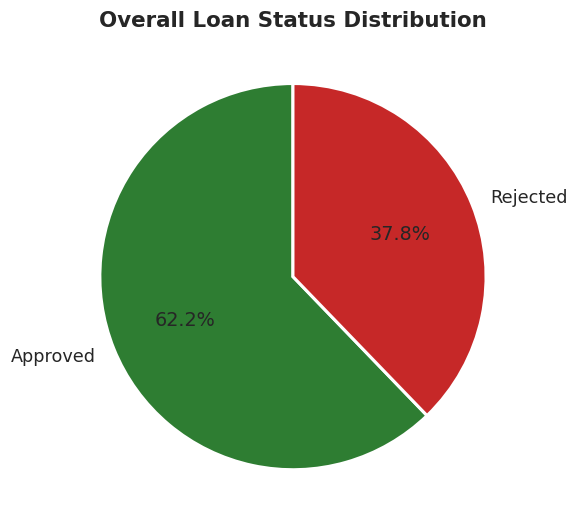

In [5]:
approval_rate = (df.loan_status == "Approved").mean() * 100
print(f"Overall approval rate: {approval_rate:.1f}%")

fig, ax = plt.subplots(figsize=(6, 5))
counts = df["loan_status"].value_counts()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
       colors=[PALETTE[k] for k in counts.index], wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Overall Loan Status Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Of the 4,269 applicants, about **62%** were approved and **38%** were
rejected — a moderately imbalanced but workable target for modeling.

### 2.2 CIBIL (credit) score — the single strongest signal

Median CIBIL - Approved: 711.0
Median CIBIL - Rejected: 429.0


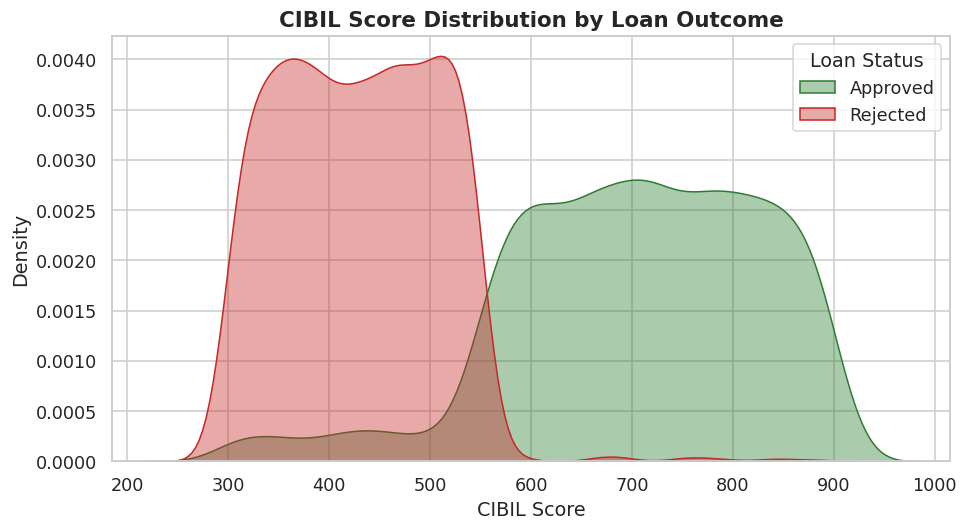

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for status, color in PALETTE.items():
    sns.kdeplot(df.loc[df.loan_status == status, "cibil_score"], fill=True,
                label=status, color=color, alpha=0.4, ax=ax)
ax.set_title("CIBIL Score Distribution by Loan Outcome", fontsize=14, fontweight="bold")
ax.set_xlabel("CIBIL Score")
ax.legend(title="Loan Status")
plt.tight_layout()
plt.show()

print("Median CIBIL - Approved:", df.loc[df.loan_status == "Approved", "cibil_score"].median())
print("Median CIBIL - Rejected:", df.loc[df.loan_status == "Rejected", "cibil_score"].median())

Approval rate, CIBIL >= 650: 99.4 %
Approval rate, CIBIL < 650: 35.1 %


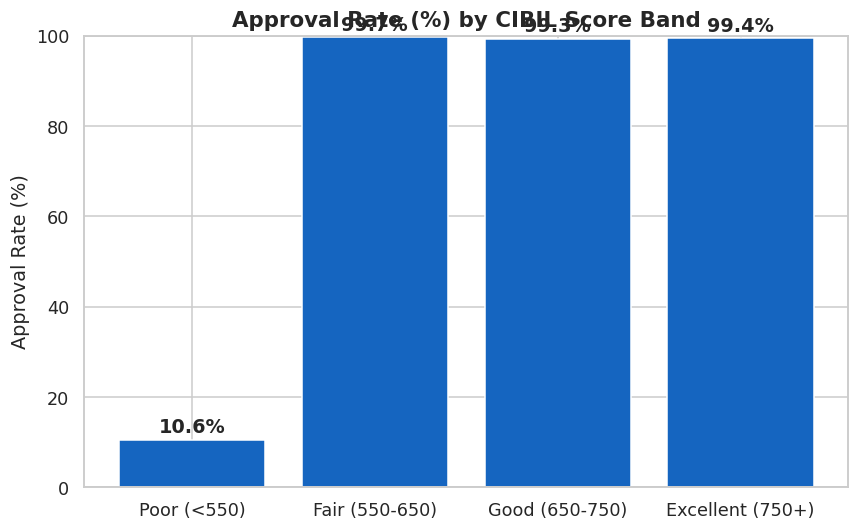

In [7]:
band_rate = (df.groupby("cibil_band", observed=True)["loan_status"]
             .apply(lambda s: (s == "Approved").mean() * 100))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(band_rate.index.astype(str), band_rate.values, color="#1565C0")
ax.set_title("Approval Rate (%) by CIBIL Score Band", fontsize=14, fontweight="bold")
ax.set_ylabel("Approval Rate (%)")
ax.set_ylim(0, 100)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f"{b.get_height():.1f}%",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("Approval rate, CIBIL >= 650:", round((df.loc[df.cibil_score >= 650, "loan_status"] == "Approved").mean()*100, 1), "%")
print("Approval rate, CIBIL < 650:", round((df.loc[df.cibil_score < 650, "loan_status"] == "Approved").mean()*100, 1), "%")

This is the headline finding of the whole analysis: applicants with a
CIBIL score **below 650 are almost always rejected (~35% approval)**,
while applicants at 650+ are **approved over 99% of the time**, regardless
of income or assets. CIBIL score functions almost like a hard cutoff in
this dataset.

### 2.3 Education & self-employment

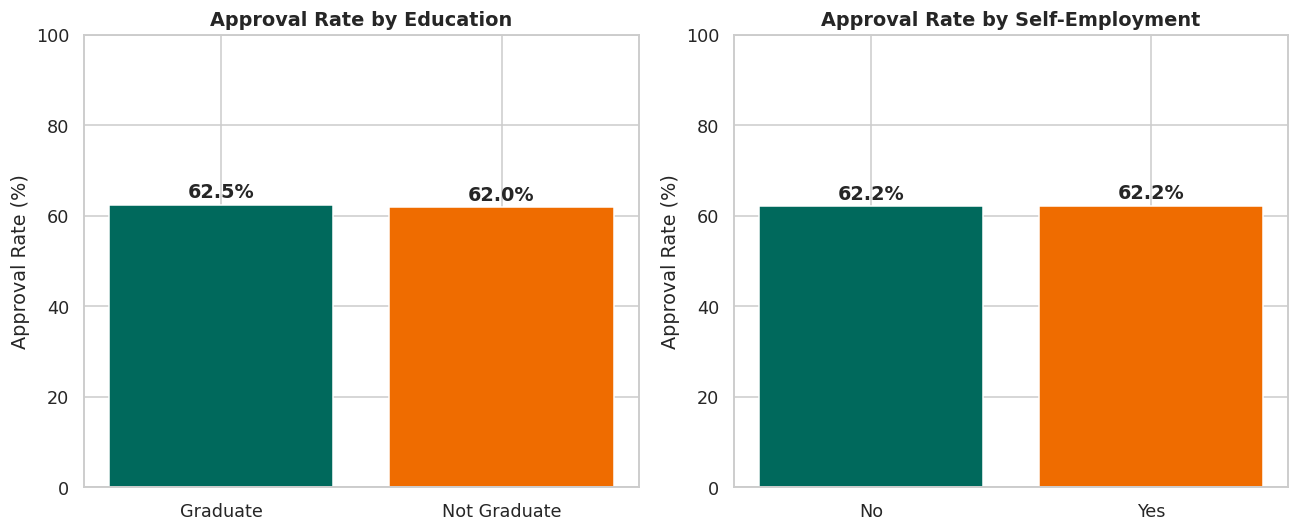

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ["education", "self_employed"],
                           ["Approval Rate by Education", "Approval Rate by Self-Employment"]):
    rate = df.groupby(col)["loan_status"].apply(lambda s: (s == "Approved").mean() * 100)
    bars = ax.bar(rate.index, rate.values, color=["#00695C", "#EF6C00"])
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Approval Rate (%)")
    ax.set_ylim(0, 100)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f"{b.get_height():.1f}%",
                ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Interestingly, education level and self-employment status show
**almost no difference** in approval rates (roughly 62% either way).
These fields carry little predictive power on their own in this dataset.

### 2.4 Income vs. loan amount

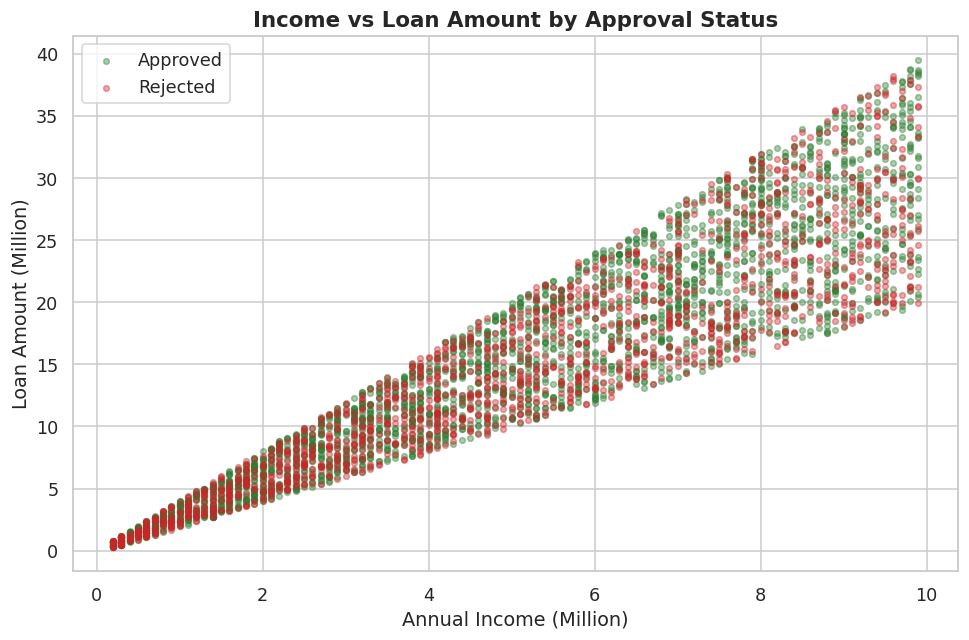

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
for status, color in PALETTE.items():
    sub = df[df.loan_status == status]
    ax.scatter(sub["income_annum"]/1e6, sub["loan_amount"]/1e6, s=14, alpha=0.4,
               color=color, label=status)
ax.set_xlabel("Annual Income (Million)")
ax.set_ylabel("Loan Amount (Million)")
ax.set_title("Income vs Loan Amount by Approval Status", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

Approved and rejected applicants overlap heavily across the
income/loan-amount space — confirming that raw income and loan size alone
don't separate the classes well; it's the ratio and the credit score that matter more.

### 2.5 Loan-to-income ratio

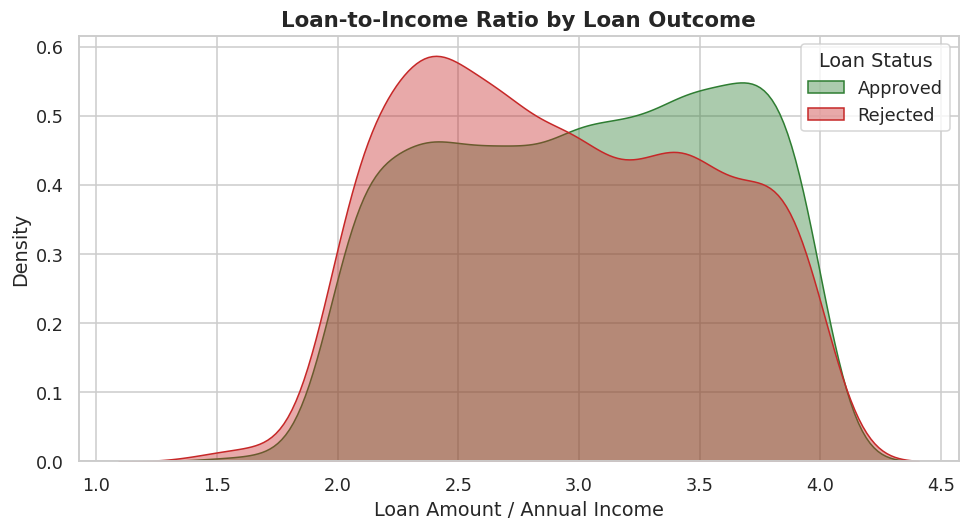

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for status, color in PALETTE.items():
    sns.kdeplot(df.loc[df.loan_status == status, "loan_to_income_ratio"], fill=True,
                label=status, color=color, alpha=0.4, ax=ax)
ax.set_title("Loan-to-Income Ratio by Loan Outcome", fontsize=14, fontweight="bold")
ax.set_xlabel("Loan Amount / Annual Income")
ax.legend(title="Loan Status")
plt.tight_layout()
plt.show()

### 2.6 Total assets by approval status

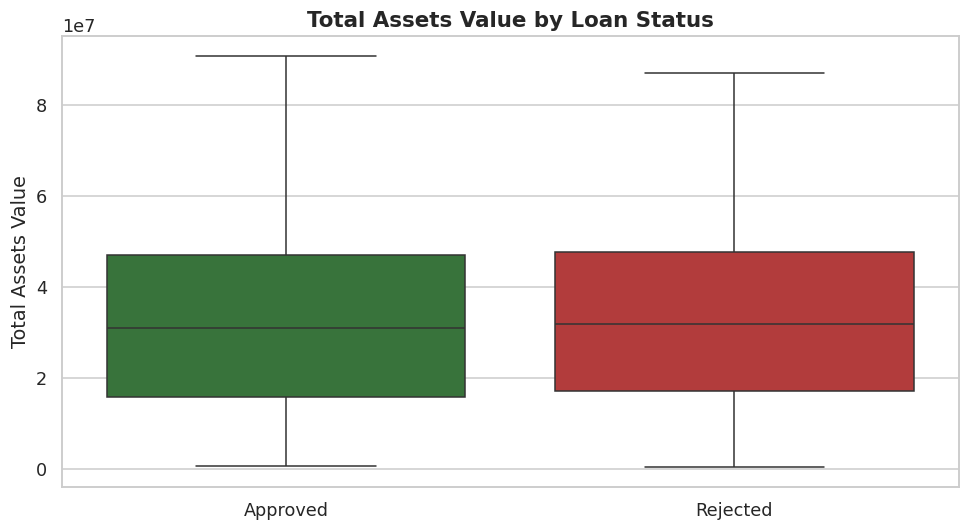

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="loan_status", y="total_assets_value", hue="loan_status",
            palette=PALETTE, legend=False, ax=ax)
ax.set_title("Total Assets Value by Loan Status", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Assets Value")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 2.7 Loan term & number of dependents

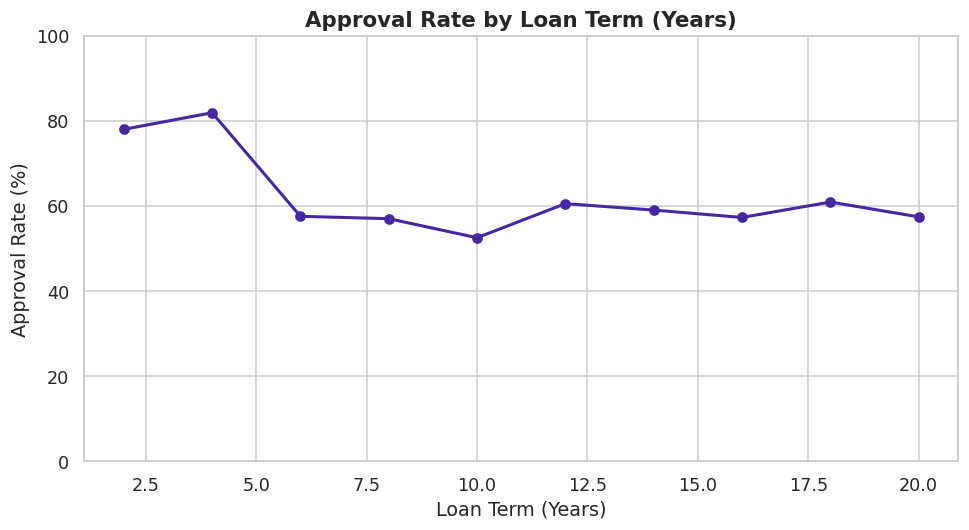

In [12]:
term_rate = df.groupby("loan_term")["loan_status"].apply(lambda s: (s == "Approved").mean() * 100)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(term_rate.index, term_rate.values, marker="o", color="#4527A0", linewidth=2)
ax.set_title("Approval Rate by Loan Term (Years)", fontsize=14, fontweight="bold")
ax.set_xlabel("Loan Term (Years)")
ax.set_ylabel("Approval Rate (%)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

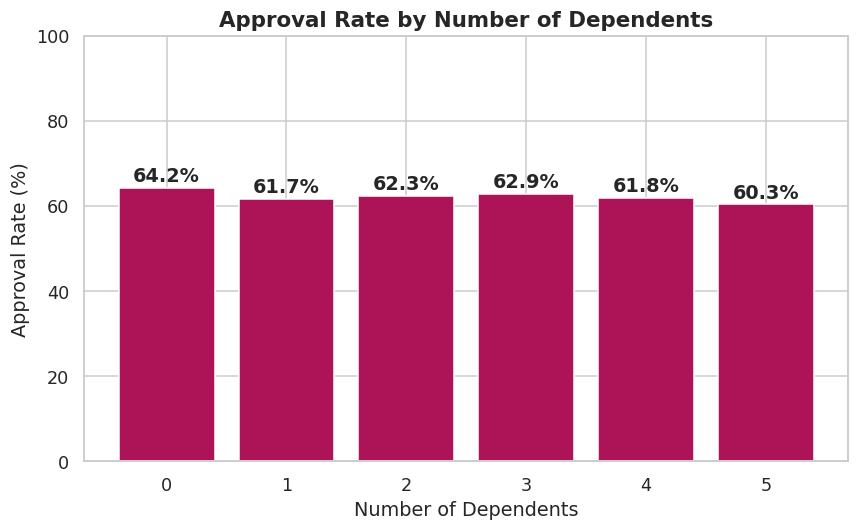

In [13]:
dep_rate = df.groupby("no_of_dependents")["loan_status"].apply(lambda s: (s == "Approved").mean() * 100)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dep_rate.index.astype(str), dep_rate.values, color="#AD1457")
ax.set_title("Approval Rate by Number of Dependents", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Dependents")
ax.set_ylabel("Approval Rate (%)")
ax.set_ylim(0, 100)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f"{b.get_height():.1f}%",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Loan term and number of dependents show **no meaningful relationship**
with approval outcome — both hover close to the overall 62% base rate.

## 3. Feature Correlation  <a id='3'></a>

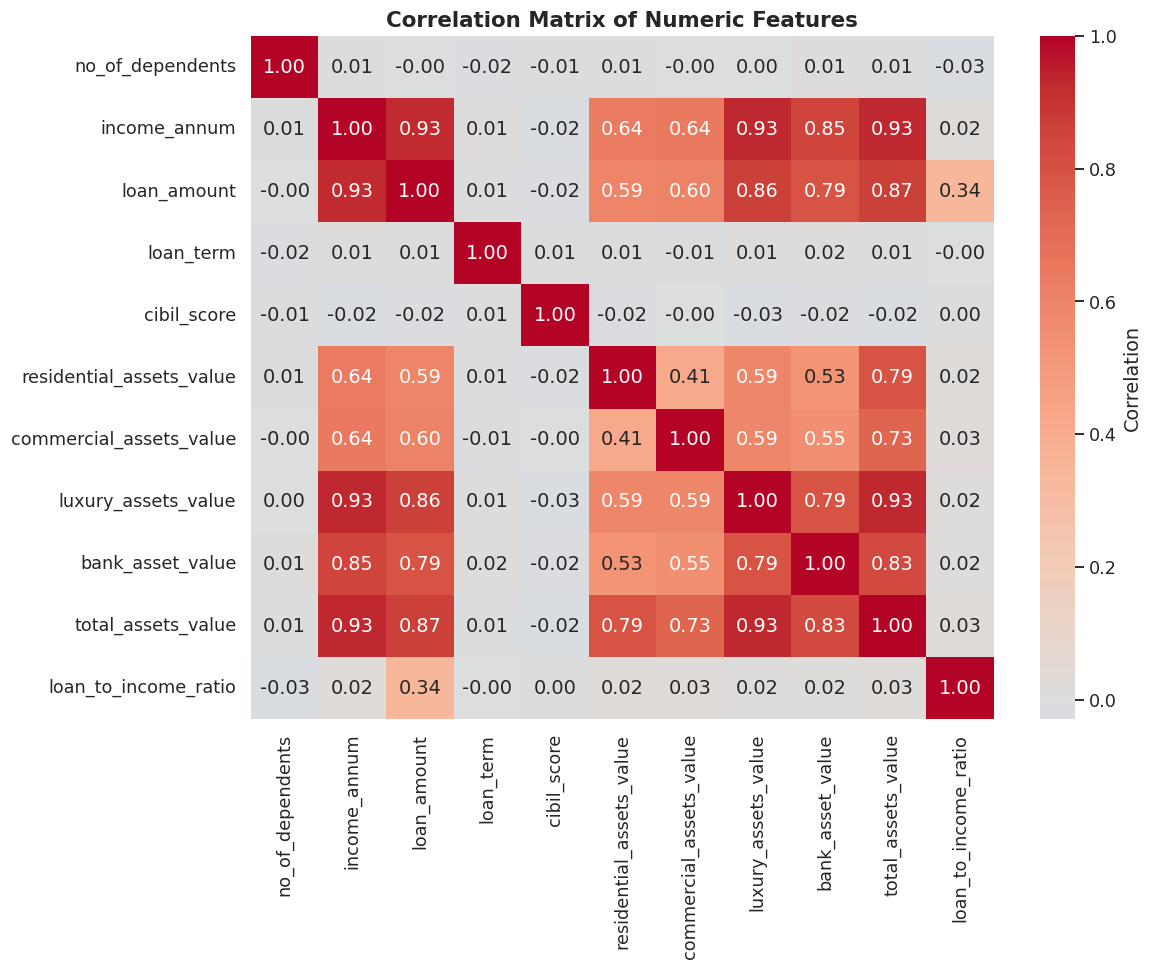

In [14]:
numeric_cols = ["no_of_dependents", "income_annum", "loan_amount", "loan_term",
                "cibil_score", "residential_assets_value", "commercial_assets_value",
                "luxury_assets_value", "bank_asset_value", "total_assets_value",
                "loan_to_income_ratio"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Matrix of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
target_corr = np.corrcoef(df["cibil_score"], (df["loan_status"] == "Approved").astype(int))[0, 1]
print(f"Correlation between CIBIL score and approval (0/1): {target_corr:.3f}")

Correlation between CIBIL score and approval (0/1): 0.771


Asset values (residential, commercial, luxury, bank) are all
**strongly correlated with each other and with loan amount** — wealthier
applicants request bigger loans, as expected. CIBIL score, however, stands
apart: it correlates with the approval outcome far more strongly (**r ≈ 0.77**)
than any financial variable does, confirming it's the dominant driver.

## 4. Predictive Modeling  <a id='4'></a>

We frame this as a binary classification problem (Approved = 1,
Rejected = 0) and compare a simple **Logistic Regression** baseline
against a **Random Forest** model.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)

df_model = df.copy()
df_model["education"] = (df_model["education"] == "Graduate").astype(int)
df_model["self_employed"] = (df_model["self_employed"] == "Yes").astype(int)
df_model["target"] = (df_model["loan_status"] == "Approved").astype(int)

features = ["no_of_dependents", "education", "self_employed", "income_annum",
            "loan_amount", "loan_term", "cibil_score", "residential_assets_value",
            "commercial_assets_value", "luxury_assets_value", "bank_asset_value"]

X = df_model[features]
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 3415 | Test size: 854


In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_s, y_train)
        pred = model.predict(X_test_s)
        proba = model.predict_proba(X_test_s)[:, 1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model, "pred": pred, "proba": proba,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    }
    print(f"\n{name}")
    for k in ["accuracy", "precision", "recall", "f1"]:
        print(f"  {k:10s}: {results[name][k]:.4f}")


Logistic Regression
  accuracy  : 0.9133
  precision : 0.9208
  recall    : 0.9416
  f1        : 0.9311

Random Forest
  accuracy  : 0.9789
  precision : 0.9794
  recall    : 0.9868
  f1        : 0.9831


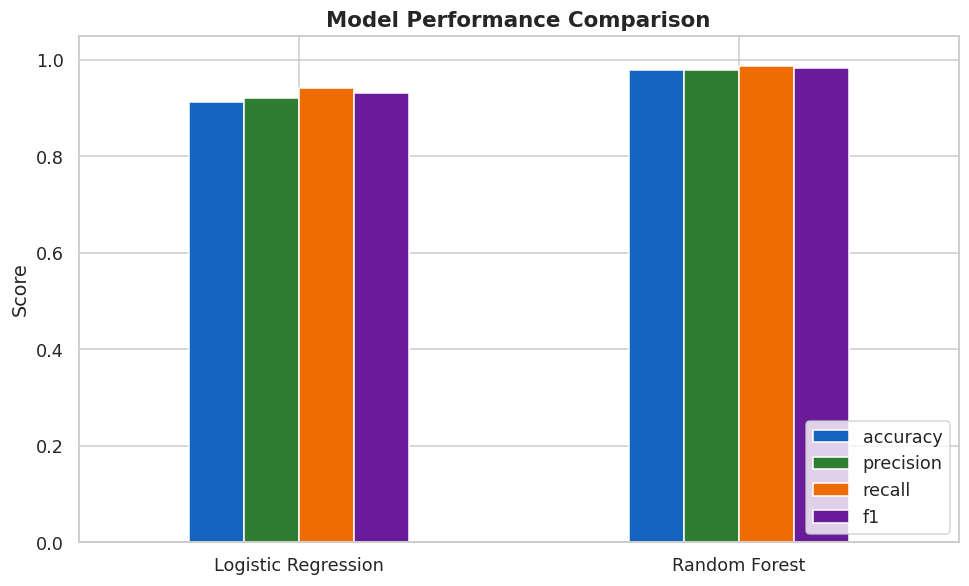

In [18]:
metrics_df = pd.DataFrame({name: {k: v[k] for k in ["accuracy", "precision", "recall", "f1"]}
                            for name, v in results.items()}).T

fig, ax = plt.subplots(figsize=(9, 5.5))
metrics_df.plot(kind="bar", ax=ax, color=["#1565C0", "#2E7D32", "#EF6C00", "#6A1B9A"])
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Best model by F1 score: Random Forest


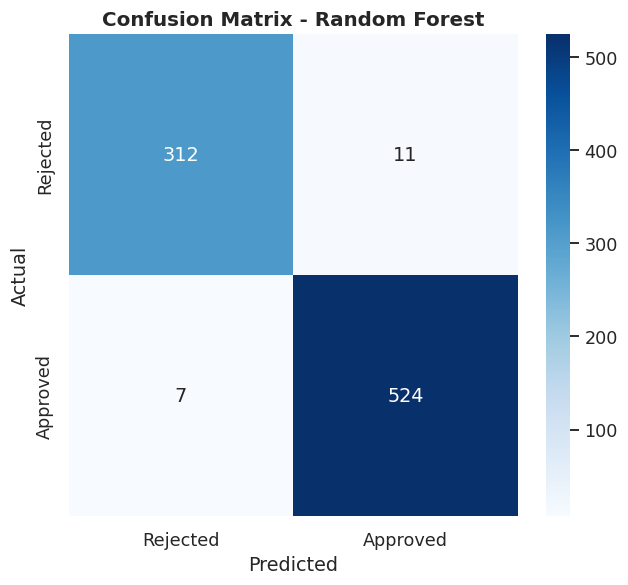

In [19]:
best_name = max(results, key=lambda k: results[k]["f1"])
cm = confusion_matrix(y_test, results[best_name]["pred"])

fig, ax = plt.subplots(figsize=(6, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
ax.set_title(f"Confusion Matrix - {best_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print("Best model by F1 score:", best_name)

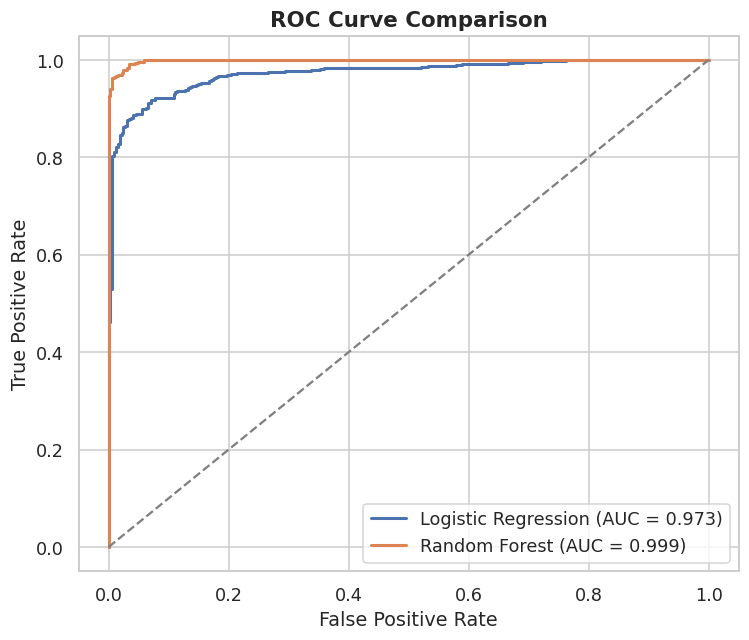

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

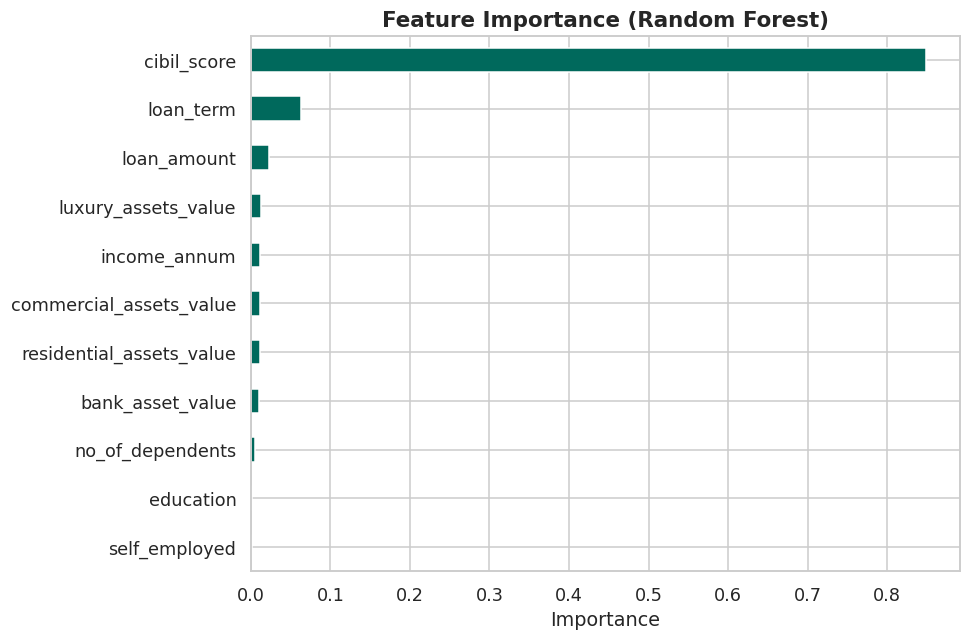

In [21]:
rf = results["Random Forest"]["model"]
importance = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind="barh", ax=ax, color="#00695C")
ax.set_title("Feature Importance (Random Forest)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

The Random Forest confirms what the EDA already suggested: **CIBIL
score dwarfs every other feature in importance**, followed at a distance
by asset values and loan amount. Education, self-employment, and
dependents contribute almost nothing to the prediction.

## 5. Conclusions & Business Recommendations  <a id='5'></a>

**Key findings:**
1. **CIBIL score is the dominant approval driver** (r ≈ 0.77 with outcome).
   Applicants scoring 650+ are approved ~99% of the time; those below 650
   are approved only ~35% of the time.
2. **Education and self-employment status are not meaningful factors** —
   approval rates are nearly identical (~62%) across both groups.
3. **Asset values and income correlate with each other but only weakly
   with approval** — high income alone does not guarantee approval if the
   credit score is poor.
4. **Loan term and number of dependents have no discernible effect** on
   the approval decision.
5. A **Random Forest classifier reaches ~98% accuracy and ~0.98 F1-score**
   on held-out data, dramatically outperforming a plain logistic
   regression baseline (~91% accuracy), largely because it can exploit
   the sharp non-linear cutoff in CIBIL score.

**Recommendations for a lending business:**
- Treat CIBIL score as the primary gating criterion in the underwriting
  workflow, since it is by far the most reliable single predictor here.
- Use income, assets, and loan-to-income ratio as secondary refinements
  for borderline (Fair/Good band) applicants rather than as standalone
  decision factors.
- Because education and self-employment carry no predictive value in this
  dataset, they should not be weighted heavily in a scoring policy — doing
  so risks introducing bias without any accuracy benefit.
- A production model should be monitored for fairness across demographic
  groups even when a feature seems statistically unimportant, since
  correlated proxies can still introduce bias.

---
*This project was built as an end-to-end portfolio piece covering data
cleaning, exploratory analysis, feature engineering, and baseline
predictive modeling.*